In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader
from Diffusion.model import Diffusion, UNet
from Diffusion.engine import diffusion_training

In [ ]:
transform = transforms.Compose([
    #UNet用に32×32とする
    transforms.Resize(32, interpolation=InterpolationMode.BICUBIC),
    # 0.8倍〜1.2倍の範囲でランダムに拡大縮小
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) #(-1, 1)にスケーリング
])

val_transform = transforms.Compose([
    transforms.Resize(64, interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
train_dataset = datasets.MNIST(root='/content/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
test_dataset = datasets.MNIST(root='/content/', train=False, download=True, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)

In [ ]:
#チャネル数、サイズがきちんと32×32になっているか確認
img, _ = train_dataset[0]
img.shape

torch.Size([1, 32, 32])

In [ ]:
#GPUに設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loss_fn = nn.MSELoss()

diffusion = Diffusion(loss_fn, device, 500, 32, 30)
model = UNet(1, diffusion)

optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=0.01
)

In [ ]:
model.to(device)

UNet(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
  (downblock1): DownBlock(
    (residual): ResidualBlock(
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (shortcut): Sequential()
    )
    (conv): Conv2d(64, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  )
  (downblock2): DownBlock(
    (residual): ResidualBlock(
      (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (shortcut): Sequential()
    )
    (conv): Conv2d(96, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1

In [ ]:
#100エポック回す
loss_train, loss_val = diffusion_training(100, optimizer, model, diffusion, train_loader, test_loader)

Epoch: 1 | Train Loss: 0.243859 | Val Loss: 0.094267
Epoch: 2 | Train Loss: 0.062073 | Val Loss: 0.043539
Epoch: 3 | Train Loss: 0.041860 | Val Loss: 0.041656
Epoch: 4 | Train Loss: 0.035921 | Val Loss: 0.048473
Epoch: 5 | Train Loss: 0.032610 | Val Loss: 0.035770
Epoch: 6 | Train Loss: 0.030500 | Val Loss: 0.042456
Epoch: 7 | Train Loss: 0.029448 | Val Loss: 0.028763
Epoch: 8 | Train Loss: 0.027991 | Val Loss: 0.034963
Epoch: 9 | Train Loss: 0.027379 | Val Loss: 0.031860
Epoch: 10 | Train Loss: 0.026673 | Val Loss: 0.035513
Epoch: 11 | Train Loss: 0.025997 | Val Loss: 0.031235
Epoch: 12 | Train Loss: 0.025640 | Val Loss: 0.034742
Epoch: 13 | Train Loss: 0.024905 | Val Loss: 0.035712
Epoch: 14 | Train Loss: 0.024809 | Val Loss: 0.035349
Epoch: 15 | Train Loss: 0.024290 | Val Loss: 0.029752
Epoch: 16 | Train Loss: 0.024050 | Val Loss: 0.033171
Epoch: 17 | Train Loss: 0.023731 | Val Loss: 0.034911
Epoch: 18 | Train Loss: 0.023509 | Val Loss: 0.031210
Epoch: 19 | Train Loss: 0.023255 | Va

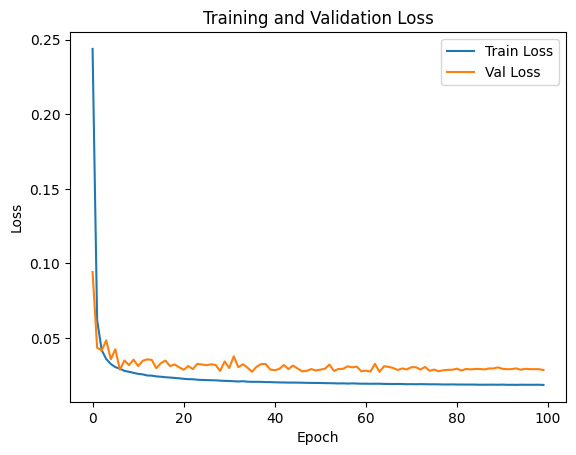

In [ ]:
#100エポック回したときの可視化
plt.plot(loss_train, label='Train Loss')
plt.plot(loss_val, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
img = diffusion.inverse(model, 1)

In [ ]:
img.shape

torch.Size([1, 1, 32, 32])

In [ ]:
# 勾配計算をオフにし、CPUへ移動してNumPy配列に変換
# サイズが1の次元（バッチとチャンネル）を消して (64, 64) にする
img_array = img.detach().cpu().squeeze().numpy()

In [ ]:
# 今の値の範囲を確認
print(f"Min: {img_array.min()}, Max: {img_array.max()}")

Min: -1.3402000665664673, Max: 1.1541104316711426


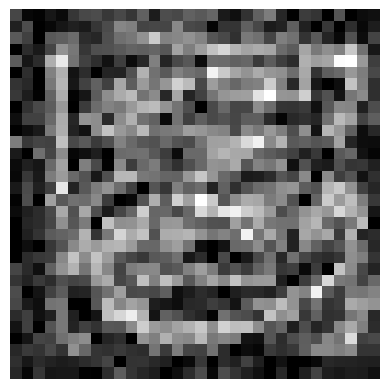

In [ ]:
#表示
plt.imshow(img_array, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')
plt.show()

In [ ]:
img = diffusion.inverse(model, 1)

In [ ]:
# 勾配計算をオフにし、CPUへ移動してNumPy配列に変換
# サイズが1の次元（バッチとチャンネル）を消して (64, 64) にする
img_array = img.detach().cpu().squeeze().numpy()

# 今の値の範囲を確認
print(f"Min: {img_array.min()}, Max: {img_array.max()}")

Min: -1.474090814590454, Max: 1.095496654510498


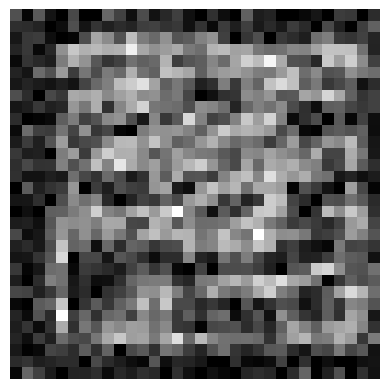

In [ ]:
#表示
plt.imshow(img_array, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')
plt.show()